# Profit Erosion Analysis - TheLook E-commerce EDA

This notebook analyzes **profit erosion driven by product returns** using the BigQuery Public Dataset `bigquery-public-data.thelook_ecommerce`.

## Analysis Focus
- **Margin reversal** on returned items (sale price - cost)
- **Profit erosion** from return processing costs
- **Customer and product segments** with high return exposure

## Notebook Structure

1. **Setup and Imports** - Load project modules from `src/`
2. **Test Data Processing Pipeline** - Validate each data processing function:
   - `load_raw_data()` - Load CSV files from BigQuery export
   - `merge_datasets()` - Merge into order-item grain
   - `engineer_return_features()` - Add return flags
   - `calculate_margins()` - Add margin calculations
   - `standardize_dtypes()` - Standardize column types
   - `build_analysis_dataset()` - Full pipeline with parquet output
3. **Data Loading** - Quality report and data preview
4. **EDA: Status Distribution** - Order item status breakdown
5. **EDA: Return Rate Analysis** - By category, brand, traffic source
6. **Margin-Focused EDA** - Margin exposure, lost sales, margin loss by category
7. **Profit Erosion Summary** - Total margin reversal + process costs
8. **Customer Segmentation** - Segment by return behavior
9. **Customer Behavioral Profile** - Detailed customer metrics and patterns
10. **Price, Margin & Cost Analysis by Status and Country** - Multi-metric comparison across geographies
11. **Data Limitations** - Return timing data availability

## Prerequisites

Raw CSV files from BigQuery in `data/raw/`:
- `order_items.csv`
- `orders.csv`
- `products.csv`
- `users.csv`

## Project Modules Used

| Module | Functions |
|--------|-----------|
| `src.config` | `RAW_DATA_DIR`, `PROCESSED_DATA_DIR`, `PROCESSED_PARQUET` |
| `src.data_processing` | `load_raw_data`, `merge_datasets`, `engineer_return_features`, `calculate_margins`, `build_analysis_dataset`, `load_processed_data` |
| `src.visualization` | `plot_status_distribution`, `plot_return_rate_by_category`, `plot_margin_distribution`, `plot_margin_loss_by_category`, `plot_customer_margin_exposure`, `plot_return_rate_heatmap`, `plot_price_margin_by_status_country` |
| `src.modeling` | `calculate_return_rates_by_group`, `calculate_margin_loss_by_group`, `summarize_profit_erosion`, `segment_customers_by_return_behavior`, `build_customer_behavior_profile`, `calculate_customer_margin_exposure`, `calculate_price_margin_by_status_country` |

## Setup and Imports

In [1]:
# Standard imports
import sys
from pathlib import Path

# Add project root to path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Reload all modules to ensure latest changes are always loaded
import importlib
modules_to_reload = ['src.config', 'src.data_cleaning', 'src.data_processing', 'src.visualization', 'src.modeling']
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, PROCESSED_PARQUET
from src.data_processing import (
    load_raw_data,
    merge_datasets,
    remove_unnecessary_columns,
    engineer_return_features,
    calculate_margins,
    standardize_dtypes,
)

# Import data cleaning functions
from src.data_cleaning import (
    perform_deep_clean,
    save_cleaned_dataset,
)

from src.visualization import (
    set_plot_style,
    plot_status_distribution,
    plot_return_rate_by_category,
    plot_margin_distribution,
    plot_margin_loss_by_category,
    plot_customer_margin_exposure,
    plot_return_rate_heatmap,
    plot_price_margin_returned_by_status_country,
)
from src.modeling import (
    calculate_return_rates_by_group,
    calculate_margin_loss_by_group,
    build_customer_behavior_profile,
    calculate_customer_margin_exposure,
    summarize_profit_erosion,
    segment_customers_by_return_behavior,
    calculate_price_margin_returned_by_country,
)

# Set plotting style
set_plot_style()

print(f"Project root: {project_root}")
print(f"Raw data dir: {RAW_DATA_DIR}")
print(f"Processed data dir: {PROCESSED_DATA_DIR}")
print("✓ All modules loaded and reloaded successfully")

Project root: c:\github\unfc-capstone-project
Raw data dir: c:\github\unfc-capstone-project\data\raw
Processed data dir: c:\github\unfc-capstone-project\data\processed
✓ All modules loaded and reloaded successfully


## Test Data Processing Pipeline

Before loading the full dataset, let's verify the data processing functions work correctly by testing them on sample data.

In [2]:
# Define columns to load for each CSV file
order_items_cols = [ 
    'id','order_id', 'product_id', 'status', 
    'shipped_at', 'delivered_at', 'returned_at', 'sale_price',
]

orders_cols = [
    'order_id','user_id','status','returned_at',
    'shipped_at','delivered_at','num_of_item'
]

products_cols = [
    'id', 'cost','category', 'brand', 'retail_price', 'department'
]

users_cols = [
    'id', 'age', 'gender', 'country', 'traffic_source','created_at'
]

In [3]:
# Test 1: Load raw data files
print("Testing load_raw_data()...")
order_items, orders, products, users = load_raw_data(
    order_items_cols=order_items_cols,
    orders_cols=orders_cols,
    products_cols=products_cols,
    users_cols=users_cols
)
print(f"  order_items: {len(order_items):,} rows, {len(order_items.columns)} columns")
print(f"  orders: {len(orders):,} rows, {len(orders.columns)} columns")
print(f"  products: {len(products):,} rows, {len(products.columns)} columns")
print(f"  users: {len(users):,} rows, {len(users.columns)} columns")

Testing load_raw_data()...
  order_items: 180,908 rows, 8 columns
  orders: 124,903 rows, 7 columns
  products: 29,120 rows, 6 columns
  users: 100,000 rows, 6 columns


In [4]:
# Test 2: Merge datasets
print("Testing merge_datasets()...")
df_merged = merge_datasets(order_items, orders, products, users)
print(f"  Merged dataset: {len(df_merged):,} rows, {len(df_merged.columns)} columns")
print(f"  Sample columns: {df_merged.columns}")

Testing merge_datasets()...
  Merged dataset: 180,908 rows, 24 columns
  Sample columns: Index(['order_item_id', 'order_id', 'product_id', 'item_status',
       'item_shipped_at', 'item_delivered_at', 'item_returned_at',
       'sale_price', 'user_id', 'order_status', 'order_shipped_at',
       'order_delivered_at', 'order_returned_at', 'num_of_item', 'cost',
       'category', 'brand', 'retail_price', 'department', 'age', 'user_gender',
       'country', 'traffic_source', 'user_created_at'],
      dtype='str')


In [5]:
# Remove unnecessary columns (order_id and product_id are redundant after merging, but keep user_id for customer analysis)
df_merged, removal_report = remove_unnecessary_columns(
    df_merged,
    columns_to_drop=['product_id']
)

print("Columns Removal Report:")
print(f"  Mode: {removal_report['mode']}")
print(f"  Initial columns: {removal_report['initial_column_count']}")
print(f"  Final columns: {removal_report['final_column_count']}")
print(f"  Columns removed: {removal_report['columns_removed']}")
print(f"  Dropped: {removal_report['columns_actually_dropped']}")
print(f"\nRemaining columns: {removal_report['remaining_columns']}")

Columns Removal Report:
  Mode: drop_mode
  Initial columns: 24
  Final columns: 23
  Columns removed: 1
  Dropped: ['product_id']

Remaining columns: ['order_item_id', 'order_id', 'item_status', 'item_shipped_at', 'item_delivered_at', 'item_returned_at', 'sale_price', 'user_id', 'order_status', 'order_shipped_at', 'order_delivered_at', 'order_returned_at', 'num_of_item', 'cost', 'category', 'brand', 'retail_price', 'department', 'age', 'user_gender', 'country', 'traffic_source', 'user_created_at']


In [6]:
# Test 3: Engineer return features
print("Testing engineer_return_features()...")
df_with_returns = engineer_return_features(df_merged)
print(f"  Added columns: is_returned_item, is_returned_order")
print(f"  Return rate: {df_with_returns['is_returned_item'].mean() * 100:.2f}%")

Testing engineer_return_features()...
  Added columns: is_returned_item, is_returned_order
  Return rate: 10.06%


In [7]:
# Test 4: Calculate margins
print("Testing calculate_margins()...")
df_with_margins = calculate_margins(df_with_returns)
print(f"  Added columns: item_margin, item_margin_pct, discount_amount, discount_pct")
print(f"  Margin columns present: {[c for c in df_with_margins.columns if 'margin' in c.lower()]}")
print(f"  Sample margin stats:")
print(f"    Mean item_margin: ${df_with_margins['item_margin'].mean():.2f}")
print(f"    Median item_margin: ${df_with_margins['item_margin'].median():.2f}")

Testing calculate_margins()...
  Added columns: item_margin, item_margin_pct, discount_amount, discount_pct
  Margin columns present: ['item_margin', 'item_margin_pct']
  Sample margin stats:
    Mean item_margin: $31.04
    Median item_margin: $20.23


In [8]:
# Test 5: Standardize data types
print("Testing standardize_dtypes()...")
df_standardized = standardize_dtypes(df_with_margins)
print(f"  Final dataset: {len(df_standardized):,} rows, {len(df_standardized.columns)} columns")
print(f"  All columns: {df_standardized.columns.tolist()}")

Testing standardize_dtypes()...
  Final dataset: 180,908 rows, 29 columns
  All columns: ['order_item_id', 'order_id', 'item_status', 'item_shipped_at', 'item_delivered_at', 'item_returned_at', 'sale_price', 'user_id', 'order_status', 'order_shipped_at', 'order_delivered_at', 'order_returned_at', 'num_of_item', 'cost', 'category', 'brand', 'retail_price', 'department', 'age', 'user_gender', 'country', 'traffic_source', 'user_created_at', 'is_returned_item', 'is_returned_order', 'discount_amount', 'discount_pct', 'item_margin', 'item_margin_pct']


In [9]:
# Preview the data
df_standardized.head()

,order_item_id,order_id,item_status,item_shipped_at,item_delivered_at,item_returned_at,sale_price,user_id,order_status,order_shipped_at,...,user_gender,country,traffic_source,user_created_at,is_returned_item,is_returned_order,discount_amount,discount_pct,item_margin,item_margin_pct
0,110641,76414,Cancelled,NaT,NaT,NaT,0.02,61335,Cancelled,NaT,...,F,China,Organic,2024-11-08 18:12:00+00:00,0,0,0.0,0.0,0.0117,0.585
1,7853,5466,Complete,2025-06-24 18:11:46+00:00,2025-06-26 01:55:46+00:00,NaT,0.02,4461,Complete,2025-06-24 18:11:46+00:00,...,F,China,Organic,2025-05-23 11:47:00+00:00,0,0,0.0,0.0,0.0117,0.585
2,114425,79025,Complete,2025-12-25 00:54:06+00:00,2025-12-26 03:59:06+00:00,NaT,0.02,63450,Complete,2025-12-25 00:54:06+00:00,...,F,Spain,Search,2025-07-10 00:11:00+00:00,0,0,0.0,0.0,0.0117,0.585
3,167396,115509,Complete,2022-04-25 13:35:52+00:00,2022-04-27 02:46:52+00:00,NaT,0.02,92500,Complete,2022-04-25 13:35:52+00:00,...,F,Brasil,Search,2020-12-15 15:48:00+00:00,0,0,0.0,0.0,0.0117,0.585
4,9435,6560,Processing,NaT,NaT,NaT,0.02,5325,Processing,NaT,...,F,China,Search,2020-04-07 17:53:00+00:00,0,0,0.0,0.0,0.0117,0.585


In [10]:
# Check columns
print(f"Total columns: {len(df_standardized.columns)}")
df_standardized.columns.tolist()

Total columns: 29


['order_item_id',
 'order_id',
 'item_status',
 'item_shipped_at',
 'item_delivered_at',
 'item_returned_at',
 'sale_price',
 'user_id',
 'order_status',
 'order_shipped_at',
 'order_delivered_at',
 'order_returned_at',
 'num_of_item',
 'cost',
 'category',
 'brand',
 'retail_price',
 'department',
 'age',
 'user_gender',
 'country',
 'traffic_source',
 'user_created_at',
 'is_returned_item',
 'is_returned_order',
 'discount_amount',
 'discount_pct',
 'item_margin',
 'item_margin_pct']

## EDA: Order Item Status Distribution

In [11]:
# Item status distribution using pandas
status_dist = (
    df_standardized.groupby("item_status")
    .agg(
        count=("item_status", "size"),
        avg_cost=("cost", "mean"),
        total_cost=("cost", "sum"),
        avg_retail_price=("retail_price", "mean"),
        total_retail_price=("retail_price", "sum"),
        avg_margin=("item_margin", "mean"),
        total_margin=("item_margin", "sum"),
    )
    .sort_values("count", ascending=False)
)
status_dist

,count,avg_cost,total_cost,avg_retail_price,total_retail_price,avg_margin,total_margin
item_status,,,,,,,
Shipped,53931,28.499101,1.536985e+06,59.246187,3.195206e+06,30.747086,1.658221e+06
Complete,45277,28.765458,1.302414e+06,59.829361,2.708894e+06,31.063903,1.406480e+06
Processing,36215,28.987547,1.049784e+06,60.362332,2.186022e+06,31.374785,1.136238e+06
Cancelled,27277,28.793023,7.853873e+05,59.960465,1.635542e+06,31.167442,8.501543e+05
Returned,18208,28.717831,5.228943e+05,59.709403,1.087189e+06,30.991572,5.642945e+05


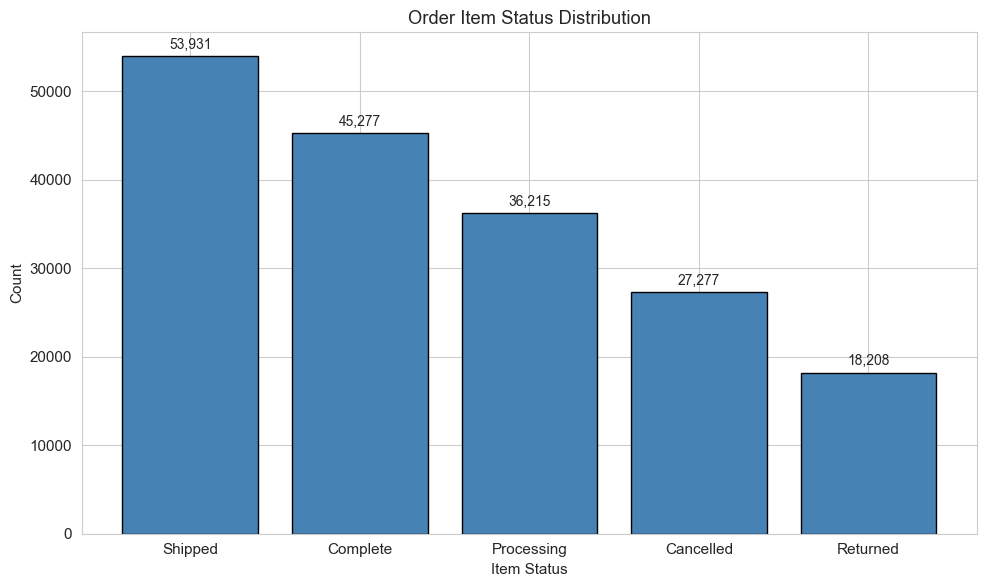

In [12]:
# Visualize status distribution
fig = plot_status_distribution(df_standardized)
plt.show()

## EDA: Return Rate Analysis

In [13]:
# Return rate by category and brand using modeling module
ret_by_cat_brand = calculate_return_rates_by_group(
    df_standardized, 
    group_cols=["category", "brand"], 
    min_rows=200
)
ret_by_cat_brand.head(25)

,,item_rows,returned_items,return_rate
category,brand,,,
Shorts,American Apparel,204,31,0.151961
Tops & Tees,Harley-Davidson,207,31,0.149758
Active,ExOfficio,217,32,0.147465
Pants,Orvis,217,32,0.147465
Maternity,Three Seasons Maternity,253,36,0.142292
Shorts,O'Neill,239,32,0.133891
Suits & Sport Coats,Allegra K,347,46,0.132565
Maternity,A Pea in the Pod,234,31,0.132479
Socks,Hanes,210,27,0.128571


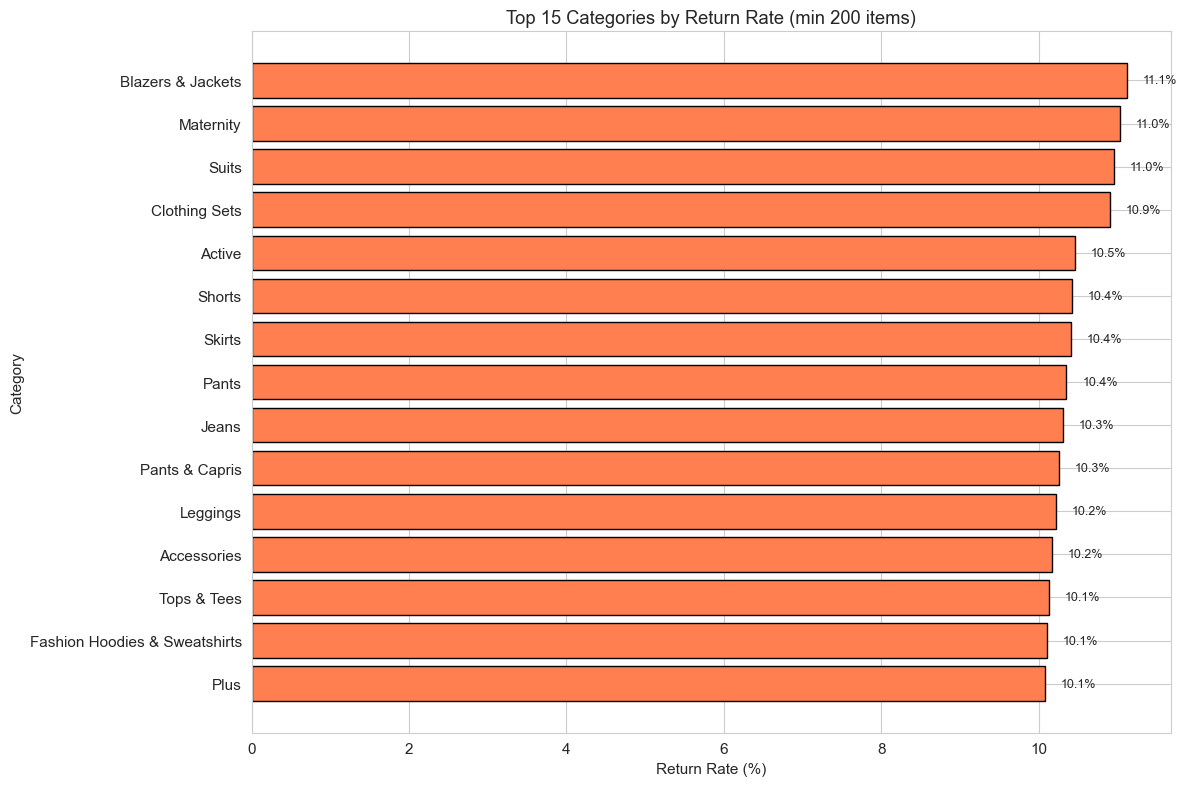

In [14]:
# Visualize return rates by category
fig = plot_return_rate_by_category(df_standardized, top_n=15, min_rows=200)
plt.show()

In [15]:
# Return rate by traffic source, country, and gender
ret_by_acq_geo = calculate_return_rates_by_group(
    df_standardized, 
    group_cols=["traffic_source", "country", "user_gender"], 
    min_rows=200
)
ret_by_acq_geo.head(25)

,,,item_rows,returned_items,return_rate
traffic_source,country,user_gender,,,
Facebook,United Kingdom,F,240,33,0.1375
Organic,Germany,F,511,67,0.131115
Display,United Kingdom,M,207,27,0.130435
Facebook,Germany,M,243,31,0.127572
Email,United States,M,1123,143,0.127337
Organic,United Kingdom,F,589,73,0.123939
Facebook,South Korea,M,277,34,0.122744
Organic,Australia,M,280,34,0.121429
Facebook,United States,M,1131,137,0.121132


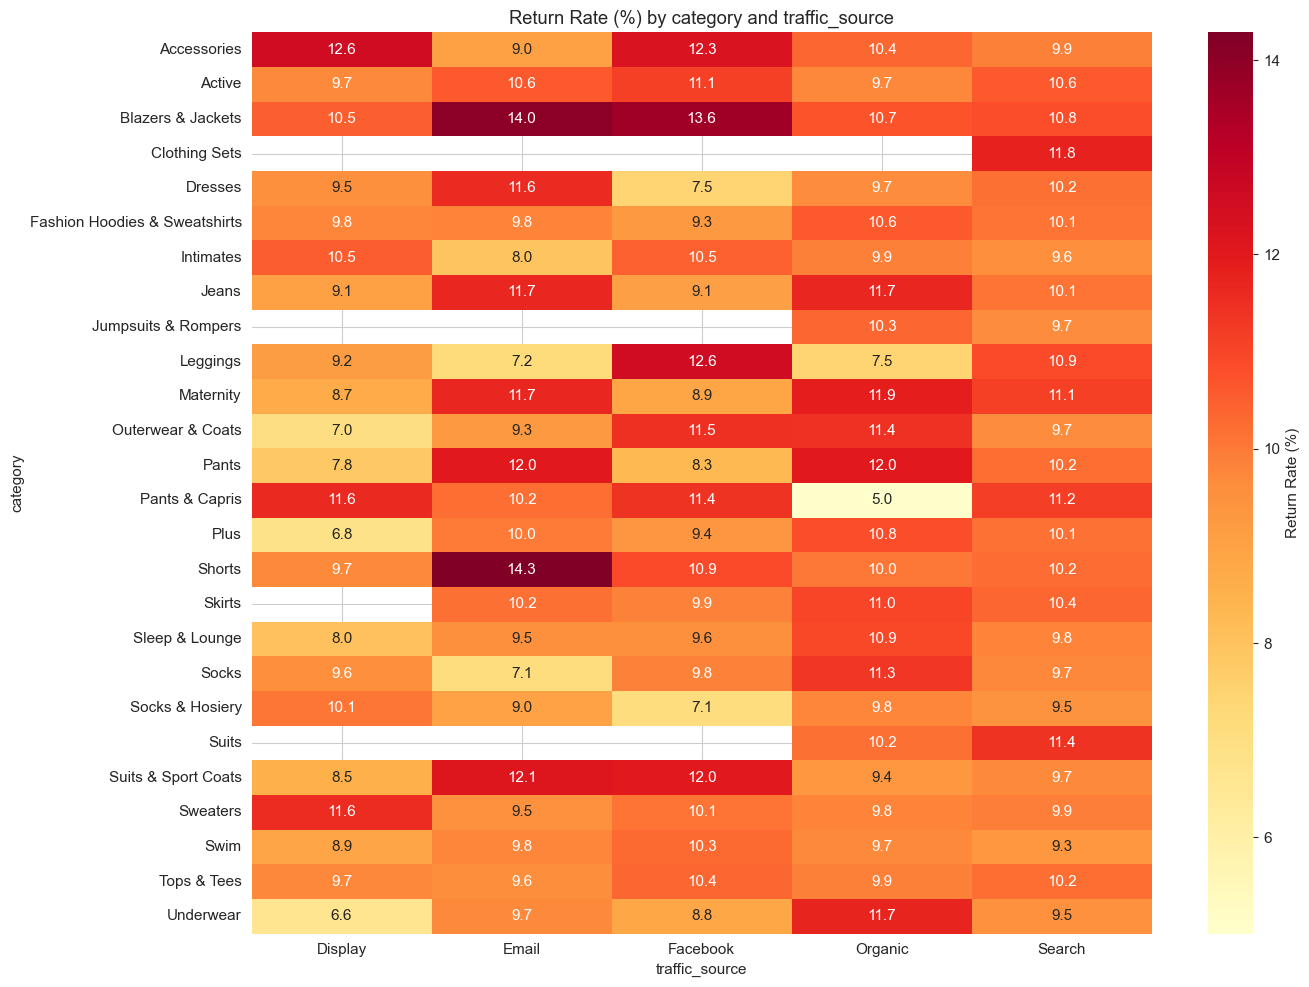

In [16]:
# Return rate heatmap: Category vs Traffic Source
fig = plot_return_rate_heatmap(
    df_standardized, 
    row_col="category", 
    col_col="traffic_source", 
    min_rows=100
)
plt.show()

## Margin-Focused EDA (Pre-Process Costs)

### Theme 1: Margin Exposure per Return Event

**Key Questions:**
1. What is the distribution of margin dollars on returned items?
2. Are returns predominantly low-margin or high-margin exposures?
3. How fat is the upper tail (large margin reversals)?

In [17]:
# Margin distribution for returned items
returned_margin = df_standardized.loc[df_standardized["is_returned_item"] == 1, "item_margin"]
returned_margin.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    18208.000000
mean        30.991572
std         36.232896
min          0.312620
10%          6.964300
25%         11.775000
50%         20.515156
75%         36.288000
90%         66.182473
99%        166.860750
max        535.478999
Name: item_margin, dtype: float64

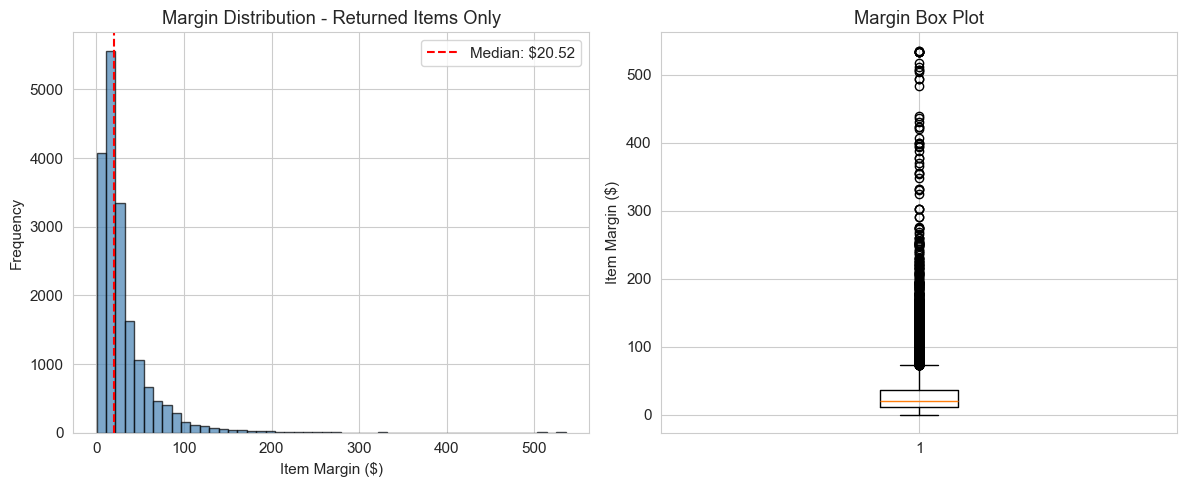

In [18]:
# Visualize margin distribution for returned items
fig = plot_margin_distribution(df_standardized, returned_only=True)
plt.show()

### Theme 2: Lost Sales Value on Returned Items

Here, lost sales means reversed revenue, not opportunity cost.

**This answers:**
- Are returns economically concentrated?
- Do a small number of returns drive disproportionate revenue reversals?

In [19]:
# Sales distribution for returned items
returned_sales = df_standardized.loc[df_standardized["is_returned_item"] == 1, "sale_price"]
returned_sales.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    18208.000000
mean        59.709403
std         65.476488
min          0.490000
10%         13.990000
25%         24.772501
50%         40.000000
75%         69.989998
90%        128.000000
99%        299.000000
max        999.000000
Name: sale_price, dtype: float64

### Theme 3: Margin Loss by Product Context

**Questions:**
- Which categories account for the largest absolute margin loss?
- Do some categories combine high margin per item with returns?

In [20]:
# Margin loss by category using modeling module
margin_loss_by_category = calculate_margin_loss_by_group(df_standardized, group_cols=["category"])
margin_loss_by_category.head(15)

,returned_items,total_lost_sales,total_lost_margin,median_margin_per_return,avg_margin_per_return
category,,,,,
Outerwear & Coats,931,137944.849823,76693.733705,60.496000,82.377802
Jeans,1286,123909.350129,57359.967938,35.875174,44.603397
Sweaters,1109,85196.299951,44052.767296,31.107509,39.722964
Suits & Sport Coats,492,61166.229997,36525.572048,56.794319,74.238968
Fashion Hoodies & Sweatshirts,1192,64985.290035,31203.595301,23.518600,26.177513
Sleep & Lounge,1094,57169.620177,29629.574551,19.971220,27.083706
Swim,1069,60293.780057,29523.019460,22.535309,27.617418
Active,947,46321.120052,26747.333446,19.437000,28.244280
Accessories,996,43717.559963,26296.765952,15.035990,26.402375


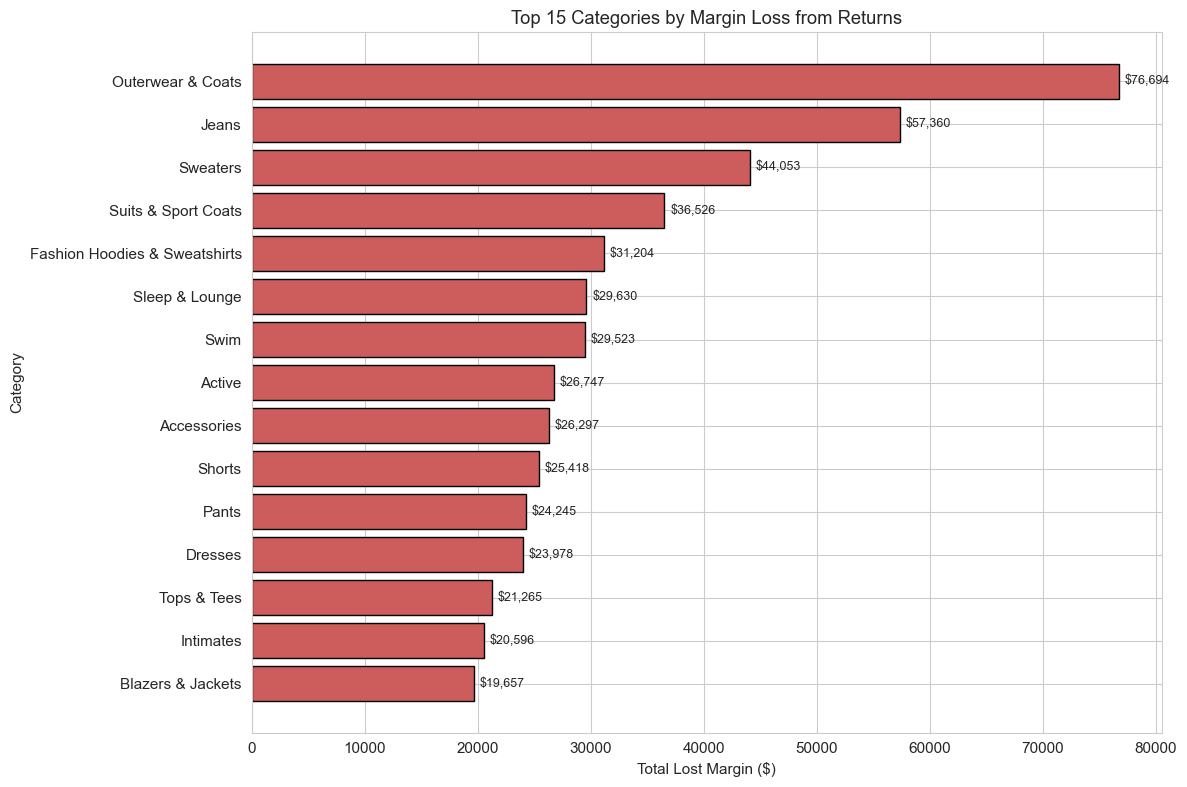

In [21]:
# Visualize margin loss by category
fig = plot_margin_loss_by_category(df_standardized, top_n=15)
plt.show()

### Theme 4: Customer-Level Margin Exposure from Returns

**Questions:**
- Are margin losses dispersed or concentrated among customers?
- Do some customers generate high cumulative margin reversals?

In [22]:
# Customer margin exposure using modeling module
customer_exposure = calculate_customer_margin_exposure(df_standardized)
customer_exposure.head(20)

,return_events,total_lost_margin,total_lost_sales,median_margin_per_return,max_single_return_margin
user_id,,,,,
46358,5,660.286698,1230.989998,36.476199,507.485999
73088,4,601.724230,1030.820002,29.405225,535.478999
9592,2,560.598027,991.769997,280.299013,503.873999
73720,2,555.082019,945.990002,277.541010,533.672998
48158,2,545.759348,925.990000,272.879674,532.769998
34216,1,535.478999,903.000000,535.478999,535.478999
79918,2,534.529997,1040.000000,267.264999,511.829997
7008,1,533.672998,903.000000,533.672998,533.672998
51888,1,532.769998,903.000000,532.769998,532.769998


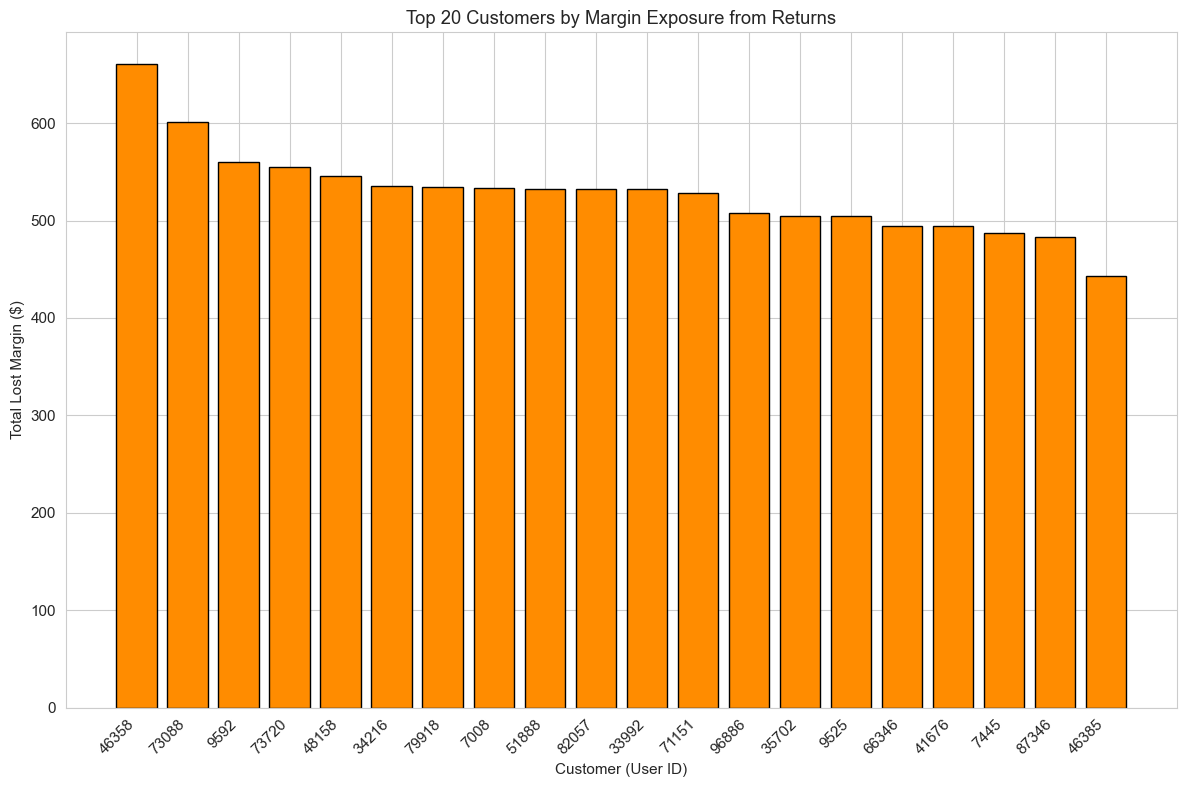

In [23]:
# Visualize customer margin exposure
fig = plot_customer_margin_exposure(df_standardized, top_n=20)
plt.show()


## Profit Erosion Summary

This section combines margin reversal with estimated return processing costs to calculate total profit erosion.

In [24]:
# Generate profit erosion summary
erosion_summary = summarize_profit_erosion(df_standardized, cost_per_return=15.0)

print("=" * 50)
print("PROFIT EROSION SUMMARY")
print("=" * 50)
print(f"Total items analyzed: {erosion_summary['total_items']:,}")
print(f"Total returned items: {erosion_summary['total_returned']:,}")
print(f"Return rate: {erosion_summary['return_rate_pct']:.2f}%")
print()
print(f"Total margin reversal: ${erosion_summary['total_margin_reversal']:,.2f}")
print(f"Avg margin per return: ${erosion_summary['avg_margin_per_return']:.2f}")
print(f"Median margin per return: ${erosion_summary['median_margin_per_return']:.2f}")
print(f"Max single margin loss: ${erosion_summary['max_single_margin_loss']:.2f}")
print()
print(f"Estimated process costs (@$15/return): ${erosion_summary['estimated_process_costs']:,.2f}")
print(f"TOTAL PROFIT EROSION: ${erosion_summary['total_profit_erosion']:,.2f}")
print()
print(f"% of total margin lost to returns: {erosion_summary['pct_margin_lost_to_returns']:.2f}%")
print("=" * 50)

PROFIT EROSION SUMMARY
Total items analyzed: 180,908
Total returned items: 18,208
Return rate: 10.06%

Total margin reversal: $564,294.54
Avg margin per return: $30.99
Median margin per return: $20.52
Max single margin loss: $535.48

Estimated process costs (@$15/return): $273,120.00
TOTAL PROFIT EROSION: $837,414.54

% of total margin lost to returns: 10.05%


## Customer Segmentation by Return Behavior

In [25]:
# Segment customers by return behavior
customer_segments = segment_customers_by_return_behavior(
    df_standardized, 
    return_rate_thresholds=(0.05, 0.15)
)

# Segment distribution
segment_counts = customer_segments["return_segment"].value_counts()
print("Customer Segment Distribution:")
print(segment_counts)
print()
print(f"Total customers: {len(customer_segments):,}")

Customer Segment Distribution:
return_segment
no_returns           67956
high_returner        11718
moderate_returner      270
Name: count, dtype: int64

Total customers: 79,944


In [26]:
# Analyze segments
segment_summary = (
    customer_segments
    .groupby("return_segment")
    .agg(
        customer_count=("total_items", "count"),
        avg_items=("total_items", "mean"),
        avg_returns=("return_events", "mean"),
        avg_return_rate=("return_rate", "mean"),
        total_margin=("total_margin", "sum"),
    )
    .round(2)
)
segment_summary

,customer_count,avg_items,avg_returns,avg_return_rate,total_margin
return_segment,,,,,
high_returner,11718,2.76,1.53,0.68,998687.15
moderate_returner,270,7.54,1.00,0.13,62615.91
no_returns,67956,2.16,0.00,0.00,4554085.07


## Customer Behavioral Profile

In [27]:
# Build customer behavior profile using modeling module
customer_behavior = build_customer_behavior_profile(df_standardized)
customer_behavior.describe()

,total_items,total_orders,return_events,total_sales,total_margin,avg_item_price,avg_item_margin,avg_discount_pct,delivered_items,return_rate,items_per_order
count,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.0,79944.000000,79944.000000,79944.000000
mean,2.262934,1.562381,0.227759,135.255333,70.241521,59.951178,31.157664,0.0,0.773817,0.100789,1.449275
std,1.600215,0.859629,0.643842,138.479309,74.077067,54.003167,29.776293,0.0,1.129507,0.269227,0.716939
min,1.000000,1.000000,0.000000,0.490000,0.312620,0.490000,0.312620,0.0,0.000000,0.000000,1.000000
25%,1.000000,1.000000,0.000000,42.000000,21.076000,29.990000,15.000000,0.0,0.000000,0.000000,1.000000
50%,2.000000,1.000000,0.000000,89.500000,45.737684,46.975000,23.588643,0.0,0.000000,0.000000,1.000000
75%,3.000000,2.000000,0.000000,182.490000,94.136147,71.970000,37.288034,0.0,1.000000,0.000000,2.000000
max,13.000000,4.000000,8.000000,1733.430000,981.555083,999.000000,568.099998,0.0,10.000000,1.000000,4.000000


## Price, Margin & Cost Analysis by Country (Returned Items Only)

Analyze cost, price, and margin metrics for **returned items** broken down by geographical region:
- **Row 1:** Average Cost | Total Cost
- **Row 2:** Average Sale Price | Total Sale Price  
- **Row 3:** Average Margin | Total Margin
- **Row 4:** Item Count (Volume)

Each chart shows metrics by country for items with status='Returned'.

In [28]:
# Calculate price, margin, and cost metrics by status and country
status_country_analysis = calculate_price_margin_returned_by_country(df_standardized)
print(f"Total groups: {len(status_country_analysis)}")
print(f"\nTop 20 by total margin:")
status_country_analysis.head(20)

Total groups: 13

Top 20 by total margin:


,item_count,avg_cost,total_cost,avg_sale_price,total_sale_price,avg_margin,total_margin,median_margin,min_margin,max_margin
country,,,,,,,,,,
China,6045,28.96,175073.34,60.18,363779.35,31.22,188706.01,20.49,1.18,533.67
United States,4193,28.10,117811.37,58.46,245123.75,30.36,127312.38,20.88,0.31,422.96
Brasil,2651,28.07,74410.24,58.57,155256.63,30.50,80846.39,20.06,0.89,535.48
South Korea,974,28.99,28238.14,60.12,58559.30,31.13,30321.16,21.73,1.79,370.09
Germany,834,29.78,24837.39,62.06,51756.41,32.28,26919.03,19.48,1.72,533.67
United Kingdom,829,28.91,23967.08,59.88,49640.82,30.97,25673.74,19.91,0.89,507.49
France,813,29.00,23573.47,59.90,48698.94,30.90,25125.47,20.82,2.20,532.77
Spain,715,30.01,21457.12,61.80,44185.69,31.79,22728.57,21.95,0.87,511.83
Australia,395,31.58,12472.55,66.71,26350.59,35.13,13878.04,20.34,1.64,532.77


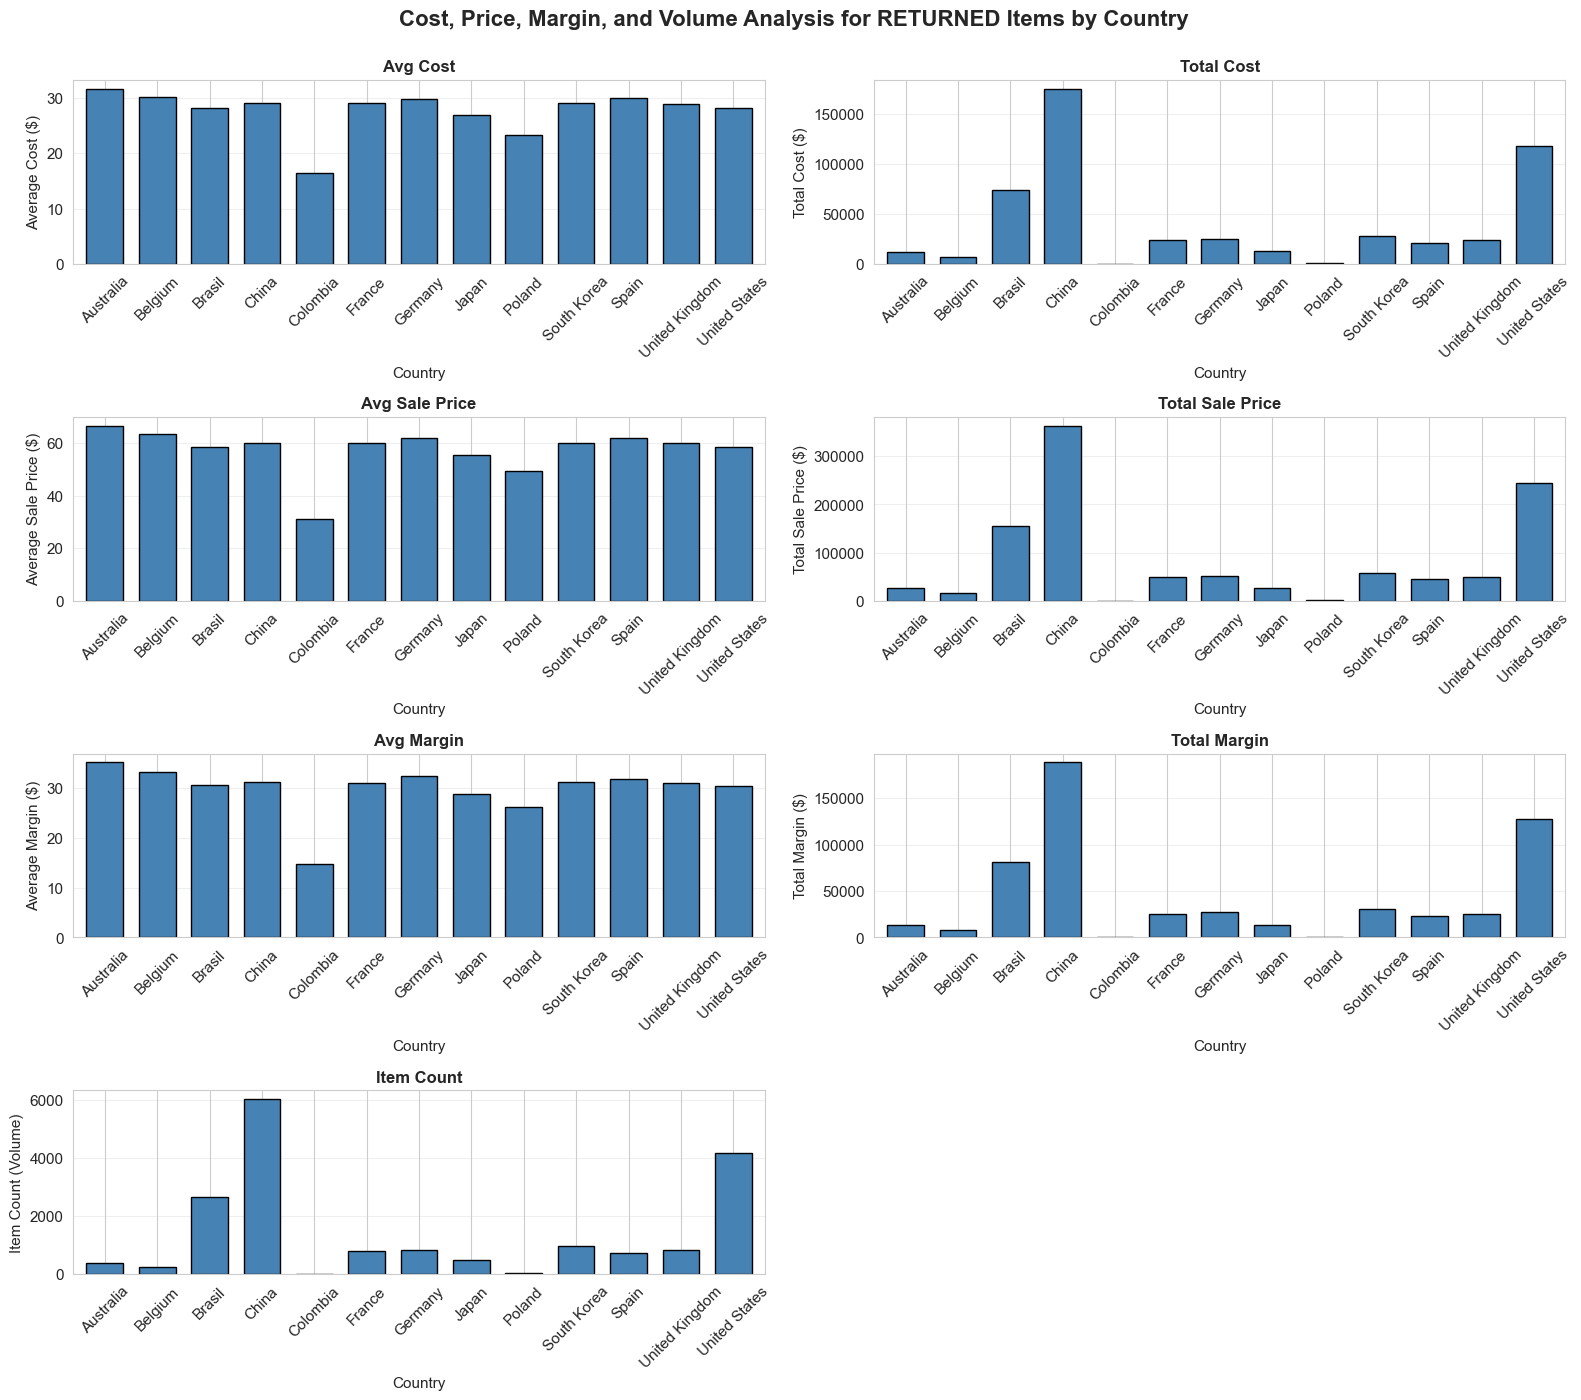

In [29]:
# Visualize price, margin, cost, and volume by status and country
# Creates a 3x2 grid of 7 bar charts: avg_cost, total_cost, avg_sale_price, total_sale_price, avg_margin, total_margin, item_count
plot_price_margin_returned_by_status_country(status_country_analysis)

## Data Limitations

**Note on Return Timing Data:**

The `returned_at` timestamp columns in the TheLook dataset are sparsely populated, which prevents return latency analysis. This is a known limitation and reinforces our methodological focus on economic exposure rather than return timing patterns.

In [30]:
# Check return timestamp availability
return_timestamp_coverage = df_standardized[[
    "item_returned_at",
    "order_returned_at",
    "item_delivered_at",
    "order_delivered_at"
]].notna().mean() * 100

print("Return/Delivery Timestamp Coverage (% non-null):")
print(return_timestamp_coverage.round(2))

Return/Delivery Timestamp Coverage (% non-null):
item_returned_at       0.24
order_returned_at      0.24
item_delivered_at     34.20
order_delivered_at    34.20
dtype: float64


## Data Cleaning Pipeline

We perform comprehensive data quality checks and cleaning using the data_cleaning module.


In [31]:
df_standardized.dtypes

order_item_id                      string
order_id                           string
item_status                           str
item_shipped_at       datetime64[us, UTC]
item_delivered_at     datetime64[us, UTC]
item_returned_at      datetime64[us, UTC]
sale_price                        float64
user_id                            string
order_status                          str
order_shipped_at      datetime64[us, UTC]
order_delivered_at    datetime64[us, UTC]
order_returned_at     datetime64[us, UTC]
num_of_item                         int64
cost                              float64
category                              str
brand                                 str
retail_price                      float64
department                            str
age                                 int64
user_gender                           str
country                               str
traffic_source                        str
user_created_at       datetime64[us, UTC]
is_returned_item                  

In [32]:
# Perform comprehensive deep cleaning
print("Performing comprehensive deep data cleaning...")
print(f"Initial dataset: {len(df_standardized):,} rows, {len(df_standardized.columns)} columns")
print()

df_cleaned, cleaning_report = perform_deep_clean( # type: ignore
    df_standardized,
    remove_duplicates=True,
    handle_missing="report",
    detect_outliers=True,
    validate_prices=True,
    validate_status=True,
    validate_temporal=True,
    clean_categories=True,
    remove_low_variance=False,
    outlier_action="flag",
    price_action="flag",
    status_action="flag",
    temporal_action="flag",
)

print(f"Cleaned dataset: {len(df_cleaned):,} rows, {len(df_cleaned.columns)} columns")
print()
print("Cleaning Report Summary:")
print("=" * 60)

Performing comprehensive deep data cleaning...
Initial dataset: 180,908 rows, 29 columns

Cleaned dataset: 180,908 rows, 35 columns

Cleaning Report Summary:


In [33]:
# Display duplicate detection results
if 'duplicates' in cleaning_report:
    dup_rep = cleaning_report['duplicates']
    print(f"DUPLICATES:")
    print(f"  Total duplicates found: {dup_rep.get('total_duplicates_found', 0):,}")
    print(f"  Action taken: {dup_rep.get('action', 'N/A')}")
    if dup_rep.get('rows_removed'):
        print(f"  Rows removed: {dup_rep.get('rows_removed', 0):,}")
    print()

DUPLICATES:
  Total duplicates found: 0
  Action taken: removed



In [34]:
# Display missing values summary
if 'missing_values' in cleaning_report:
    missing_rep = cleaning_report['missing_values']
    print(f"MISSING VALUES:")
    print(f"  Total missing cells: {missing_rep.get('total_missing_cells', 0):,}")
    print(f"  Columns with missing data: {len(missing_rep.get('columns_with_missing', []))}")
    print(f"  Action taken: {missing_rep.get('action', 'reported')}")
    if missing_rep.get('missing_summary'):
        print(f"\n  Missing value breakdown (top 5):")
        for item in missing_rep['missing_summary'][:5]:
            print(f"    {item['column']}: {item['missing_count']} ({item['missing_pct']:.2f}%)")
    print()

MISSING VALUES:
  Total missing cells: 736,910
  Columns with missing data: 8
  Action taken: reported

  Missing value breakdown (top 5):
    item_returned_at: 180465 (99.76%)
    order_returned_at: 180465 (99.76%)
    order_delivered_at: 119046 (65.80%)
    item_delivered_at: 119046 (65.80%)
    order_shipped_at: 66513 (36.77%)



In [35]:
# Display outlier detection results
if 'outliers' in cleaning_report:
    outlier_rep = cleaning_report['outliers']
    print(f"OUTLIER DETECTION (IQR Method):")
    print(f"  Total outlier rows flagged: {outlier_rep.get('total_outlier_rows', 0):,}")
    print(f"  Columns with outliers: {len(outlier_rep.get('columns_with_outliers', []))}")
    print(f"  Action taken: {outlier_rep.get('action', 'N/A')}")
    if outlier_rep.get('outlier_counts_by_column'):
        print(f"\n  Outliers by column:")
        for col, count in sorted(outlier_rep['outlier_counts_by_column'].items(), key=lambda x: x[1], reverse=True)[:5]:
            if count > 0:
                print(f"    {col}: {count:,} outliers")
    print()


OUTLIER DETECTION (IQR Method):
  Total outlier rows flagged: 39,811
  Columns with outliers: 4
  Action taken: flagged

  Outliers by column:
    num_of_item: 25,436 outliers
    sale_price: 15,514 outliers
    retail_price: 15,514 outliers
    cost: 13,812 outliers



In [36]:
# Display price consistency validation results
if 'price_consistency' in cleaning_report:
    price_rep = cleaning_report['price_consistency']
    print(f"PRICE CONSISTENCY VALIDATION:")
    print(f"  Total inconsistent rows flagged: {price_rep.get('total_inconsistent_rows', 0):,}")
    print(f"  Action taken: {price_rep.get('action', 'N/A')}")
    if price_rep.get('issue_breakdown'):
        print(f"\n  Issues found:")
        for issue, count in price_rep['issue_breakdown'].items():
            if count > 0:
                print(f"    {issue}: {count:,}")
    print()

PRICE CONSISTENCY VALIDATION:
  Total inconsistent rows flagged: 0
  Action taken: flagged

  Issues found:



In [37]:
# Display status consistency validation results
if 'status_consistency' in cleaning_report:
    status_rep = cleaning_report['status_consistency']
    print(f"STATUS CONSISTENCY VALIDATION:")
    print(f"  Total inconsistent rows flagged: {status_rep.get('total_inconsistent_rows', 0):,}")
    print(f"  Action taken: {status_rep.get('action', 'N/A')}")
    if status_rep.get('issue_breakdown'):
        print(f"\n  Issues found:")
        for issue, count in status_rep['issue_breakdown'].items():
            if count > 0:
                print(f"    {issue}: {count:,}")
    print()

STATUS CONSISTENCY VALIDATION:
  Total inconsistent rows flagged: 0
  Action taken: flagged

  Issues found:



In [38]:
# Display temporal consistency validation results
if 'temporal_consistency' in cleaning_report:
    temporal_rep = cleaning_report['temporal_consistency']
    print(f"TEMPORAL CONSISTENCY VALIDATION:")
    print(f"  Total inconsistent rows flagged: {temporal_rep.get('total_inconsistent_rows', 0):,}")
    print(f"  Action taken: {temporal_rep.get('action', 'N/A')}")
    if temporal_rep.get('issue_breakdown'):
        print(f"\n  Issues found:")
        for issue, count in temporal_rep['issue_breakdown'].items():
            if count > 0:
                print(f"    {issue}: {count:,}")
    print()

TEMPORAL CONSISTENCY VALIDATION:
  Total inconsistent rows flagged: 0
  Action taken: flagged

  Issues found:



In [39]:
# Display categorical cleaning results
if 'categorical_cleaning' in cleaning_report:
    cat_rep = cleaning_report['categorical_cleaning']
    print(f"CATEGORICAL VALUE CLEANING:")
    print(f"  Columns cleaned: {len(cat_rep.get('columns_cleaned', []))}")
    print(f"  Columns: {cat_rep.get('columns_cleaned', [])}")
    if cat_rep.get('value_replacements'):
        print(f"\n  Value consolidations:")
        for col, changes in cat_rep['value_replacements'].items():
            print(f"    {col}: {changes['before']} → {changes['after']} unique values (reduced by {changes['reduced_by']})")
    print()

print("=" * 60)
print(f"CLEANING COMPLETE")
print(f"  Rows removed: {cleaning_report['summary'].get('rows_removed', 0):,}")
print(f"  Flags added: is_outlier, has_price_inconsistency, has_status_inconsistency, has_temporal_inconsistency")

CATEGORICAL VALUE CLEANING:
  Columns cleaned: 13
  Columns: ['order_item_id', 'order_id', 'item_status', 'user_id', 'order_status', 'category', 'brand', 'department', 'user_gender', 'country', 'traffic_source', 'outlier_columns', 'outlier_values']

  Value consolidations:
    brand: 2754 → 2715 unique values (reduced by 39)

CLEANING COMPLETE
  Rows removed: 0
  Flags added: is_outlier, has_price_inconsistency, has_status_inconsistency, has_temporal_inconsistency


In [40]:
# Save the cleaned dataset
df_cleaned = save_cleaned_dataset(df_cleaned)
print(f"\n✓ Dataset successfully saved!")



✓ Dataset successfully saved!


In [41]:
# Display cleaned dataset preview
print("CLEANED DATASET PREVIEW")
print("=" * 80)
print(f"Shape: {df_cleaned.shape}")
print(f"\nFirst few rows:")
print(df_cleaned.head())
print(f"\nColumn names and types:")
print(df_cleaned.dtypes)
print(f"\nBasic statistics:")
print(df_cleaned.describe())

CLEANED DATASET PREVIEW
Shape: (180908, 29)

First few rows:
  order_item_id order_id item_status           item_shipped_at  \
0        110641    76414   cancelled                       NaT   
1          7853     5466    complete 2025-06-24 18:11:46+00:00   
2        114425    79025    complete 2025-12-25 00:54:06+00:00   
3        167396   115509    complete 2022-04-25 13:35:52+00:00   
4          9435     6560  processing                       NaT   

          item_delivered_at item_returned_at  sale_price user_id order_status  \
0                       NaT              NaT        0.02   61335    cancelled   
1 2025-06-26 01:55:46+00:00              NaT        0.02    4461     complete   
2 2025-12-26 03:59:06+00:00              NaT        0.02   63450     complete   
3 2022-04-27 02:46:52+00:00              NaT        0.02   92500     complete   
4                       NaT              NaT        0.02    5325   processing   

           order_shipped_at  ... user_gender country  t